# Reading TIFFs to CUDA memory

## Overview

In this tutorial, you learn:

* How to read a GeoTIFF into an xarray.DataArray backed by CuPy arrays

## Prerequisites

You will need to have a CUDA-enabled GPU (Volta generation or newer), and be running
on Linux, either x86_64 or aarch64 platform. Please ensure that you have installed
`cupy-xarray` with the 'tiff' extras that contains the `cog3pio` dependency, e.g. via

```bash
pip install cupy-xarray[tiff]
```

or if you are using conda, manually install `cog3pio` via

```bash
conda install -c conda-forge cog3pio cupy-xarray
```

There may be other system prerequisities needed by the underlying nvTIFF library used
by `cog3pio`, which you can check at
<https://docs.nvidia.com/cuda/nvtiff/index.html#prerequisites>

## Introduction

In this tutorial, we will learn how to read data stored in a GeoTIFF format into CUDA
GPU memory. This will use the [`cog3pio`](https://cog3pio.readthedocs.io) Python/Rust
library that contains bindings to
[nvTIFF](https://docs.nvidia.com/cuda/nvtiff/index.html) which does GPU-accelerated
decoding of TIFF (Tagged Image File Format) files.

Let's now import our packages

In [1]:
import cupy as cp
import xarray as xr

Check that the [Cog3pioBackendEntrypoint](../api.rst#module-cupy_xarray.cog3pio)
engine is available:

In [2]:
xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'cog3pio': <Cog3pioBackendEntrypoint>
   Use .tif files in Xarray
   Learn more at https://cog3pio.readthedocs.io/en/latest/,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html,
 'zarr': <ZarrBackendEntrypoint>
   Open zarr files (.zarr) using zarr in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ZarrBackendEntrypoint.html}

## Reading a single-band GeoTIFF

We'll first read a single-band GeoTIFF from the
[Cloud to Street - Microsoft Flood Dataset](https://source.coop/c2sms). Use
[`xarray.open_dataarray()`](https://docs.xarray.dev/en/stable/generated/xarray.open_dataarray.html),
passing in the HTTP URL to the .tif file, configure `engine="cog3pio"` (shorthand for
`engine=Cog3pioBackendEntrypoint`) and set the `device_id` parameter to `0` to read
into CUDA GPU 0.

In [3]:
# Read GeoTIFF into an xarray.DataArray
dataarray: xr.DataArray = xr.open_dataarray(
    filename_or_obj="https://data.source.coop/c2sms/c2smsfloods/ms-dataset-chips/3e71513a-ec54-4e9b-aae6-93a8a3648763/s2/S2A_MSIL1C_20180804T031541_N0206_R118_T48PWU_20180804T061739_09053-06778/LabelWater.tif",
    engine="cog3pio",
    device_id=0,  # cuda:0
)
dataarray

<xarray.DataArray 'raster' (band: 1, y: 512, x: 512)> Size: 262kB
[262144 values with dtype=uint8]
Coordinates:
  * band     (band) uint8 1B 0
  * y        (y) float64 4kB 1.332e+06 1.332e+06 ... 1.327e+06 1.327e+06
  * x        (x) float64 4kB 5.905e+05 5.905e+05 ... 5.956e+05 5.956e+05

In [4]:
isinstance(dataarray.data, cp.ndarray)

True

That was quick and easy wasn't it? You now have an `xarray.DataArray` with dimensions
channels/band: 1, height/y: 512 and width/x: 512 in CUDA GPU memory!

We can plot this grayscale image by calling
[`.plot.imshow()`](https://docs.xarray.dev/en/stable/generated/xarray.plot.imshow.html)
on the `xarray.DataArray`.

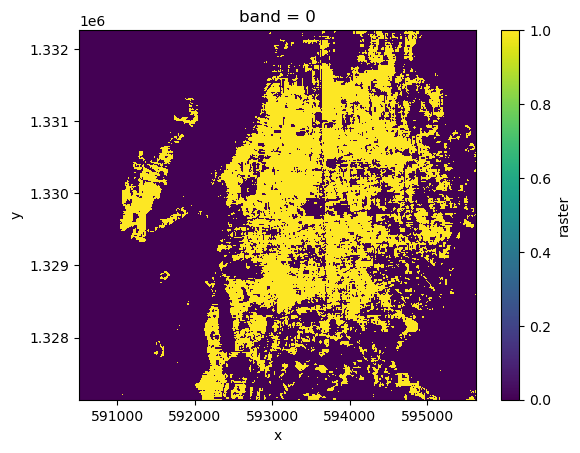

In [5]:
dataarray.isel(band=0).plot.imshow()

This shows some flooded rice paddy fields in Cambodia, with 0 being dry land and 1
being flooded water areas. You can see the location on a map by visiting this
[preview page on source.coop](https://source.coop/c2sms/c2smsfloods/ms-dataset-chips/3e71513a-ec54-4e9b-aae6-93a8a3648763/s2/S2A_MSIL1C_20180804T031541_N0206_R118_T48PWU_20180804T061739_09053-06778/LabelWater.tif).

## Concatenate multiple single-band GeoTIFFs

Let's now try a slightly trickier set up - with bands stored in different files!

We'll pull the optical satellite bands corresponding to the water mask above.
Specifically, we'll read some Sentinel-2 bands using
[`xr.open_mfdataset`](https://docs.xarray.dev/en/stable/generated/xarray.open_mfdataset.html),
ensuring that the list of URLs/filepaths correspond to the band order we want.

Note that some parameters are different than before:
- `concat_dim="band"` and `combine="nested"`: ensures that the bands are concatenated
  as data_vars along the dimension 'band'
- `device_id=None` (actually the default setting): so that the data is decoded by
  whatever GPU is available (usually this is the first CUDA GPU device, unless you are
  using dask-cuda with multiple GPUs).

In [6]:
dataset: xr.Dataset = xr.open_mfdataset(
    paths=[
        "https://data.source.coop/c2sms/c2smsfloods/ms-dataset-chips/3e71513a-ec54-4e9b-aae6-93a8a3648763/s2/S2A_MSIL1C_20180804T031541_N0206_R118_T48PWU_20180804T061739_09053-06778/B4.tif",
        "https://data.source.coop/c2sms/c2smsfloods/ms-dataset-chips/3e71513a-ec54-4e9b-aae6-93a8a3648763/s2/S2A_MSIL1C_20180804T031541_N0206_R118_T48PWU_20180804T061739_09053-06778/B3.tif",
        "https://data.source.coop/c2sms/c2smsfloods/ms-dataset-chips/3e71513a-ec54-4e9b-aae6-93a8a3648763/s2/S2A_MSIL1C_20180804T031541_N0206_R118_T48PWU_20180804T061739_09053-06778/B2.tif",
    ],
    engine="cog3pio",
    concat_dim="band",
    combine="nested",
    device_id=None,
    parallel=True,
)
dataset

<xarray.Dataset> Size: 2MB
Dimensions:  (band: 3, y: 512, x: 512)
Coordinates:
  * band     (band) uint8 3B 0 0 0
  * y        (y) float64 4kB 1.332e+06 1.332e+06 ... 1.327e+06 1.327e+06
  * x        (x) float64 4kB 5.905e+05 5.905e+05 ... 5.956e+05 5.956e+05
Data variables:
    raster   (band, y, x) uint16 2MB dask.array<chunksize=(1, 512, 512), meta=cupy.ndarray>

Next, we'll retrieve the 'raster' xarray.DataArray data_var from the xarray.Dataset,
and then call [`.compute()`](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.compute.html)
to materialize the actual array into memory. This is because `xr.open_mfdataset` does
lazy loading into Dask arrays by default, but we want CuPy arrays!

In [7]:
raster: xr.DataArray = (
    dataset.raster.compute()  # needs https://github.com/pydata/xarray/pull/11381 to prevent TypeError
)
# assert isinstance(raster.data, cp.ndarray) # TODO: dask loads into numpy, not cupy, see https://github.com/pydata/xarray/pull/11383
raster

<xarray.DataArray 'raster' (band: 3, y: 512, x: 512)> Size: 2MB
array([[[ 434,  405,  401, ...,  674,  824,  780],
        [ 432,  416,  415, ...,  667,  722,  664],
        [ 422,  411,  405, ...,  678,  702,  675],
        ...,
        [ 687,  735,  692, ...,  813,  943,  988],
        [ 734,  712,  704, ...,  725,  771,  876],
        [ 720,  680,  685, ...,  701,  700,  718]],

       [[ 785,  772,  763, ...,  941, 1004,  958],
        [ 778,  782,  761, ...,  934,  955,  901],
        [ 777,  776,  755, ...,  947,  917,  936],
        ...,
        [ 947,  971,  961, ..., 1025, 1028,  992],
        [ 996,  957,  993, ...,  969,  966,  957],
        [1004,  931,  940, ...,  911,  933,  916]],

       [[ 805,  802,  801, ...,  936,  970,  971],
        [ 812,  808,  807, ...,  928,  952,  950],
        [ 807,  806,  804, ...,  943,  948,  921],
        ...,
        [ 939,  965,  956, ..., 1043, 1034,  988],
        [ 969,  923,  954, ..., 1019, 1003,  977],
        [ 975,  932,  957, ...,  995, 1006,  985]]],
      shape=(3, 512, 512), dtype=uint16)
Coordinates:
  * band     (band) uint8 3B 0 0 0
  * y        (y) float64 4kB 1.332e+06 1.332e+06 ... 1.327e+06 1.327e+06
  * x        (x) float64 4kB 5.905e+05 5.905e+05 ... 5.956e+05 5.956e+05

Finally, we'll plot the RGB image. This is somewhere in Dambae District, Cambodia.

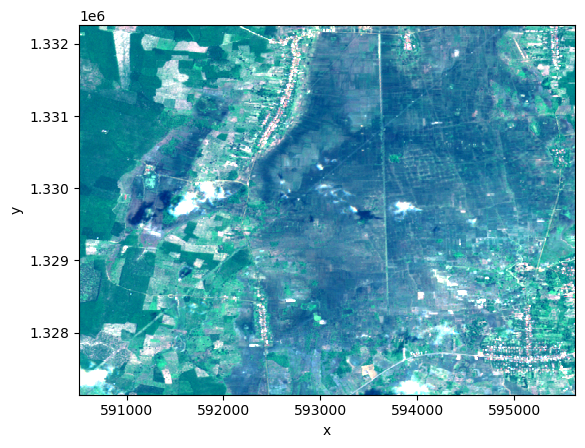

In [8]:
raster.plot.imshow(robust=True)

There's some small cloud cover in the middle, and you should be able to make out some
crop fields. See if it matches with the water label classification above!

## Summary

Awesome, you've now learned how to read GeoTIFFs into CUDA GPU memory. This is a work
in progress though with some limitations, so feel free to open issues to contribute
improvements if you're keen to help!